# 4_2. QDA ręcznie: Gaussy i granice kwadratowe

LDA zakłada, że klasy mają podobną kowariancję. QDA (*Quadratic Discriminant Analysis*) pozwala każdej klasie mieć własną wariancję/kowariancję.

W 1D dla klasy $k$:

$$
p(x\mid y=k)=\frac{1}{\sqrt{2\pi\sigma_k^2}}\exp\left(-\frac{(x-\mu_k)^2}{2\sigma_k^2}\right).
$$

W logarytmie:

$$
\log p(x\mid y=k)=
-\frac{1}{2}\log\sigma_k^2
-\frac{(x-\mu_k)^2}{2\sigma_k^2}
+\text{const}.
$$

Decyzja polega na porównaniu wyników klas:

$$
g_k(x)=\log p(x\mid y=k)+\log p(y=k).
$$

Granica decyzyjna jest tam, gdzie:

$$
g_0(x)=g_1(x).
$$

Jeżeli wariancje klas są różne, po rozpisaniu równania zostaje składnik z $x^2$. Dlatego granica QDA może być **kwadratowa**, a w 2D może być krzywą, nie tylko prostą.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.precision', 3)

# Prosty przykład 1D: klasa 0 jest bardziej skupiona, klasa 1 jest bardziej rozciągnięta.
x0 = np.array([-2.2, -1.7, -1.4, -0.8, -0.4])
x1 = np.array([0.2, 1.1, 2.0, 3.0, 4.2])
mu0, var0 = x0.mean(), x0.var(ddof=1)
mu1, var1 = x1.mean(), x1.var(ddof=1)
pd.DataFrame({'mu': [mu0, mu1], 'sigma^2': [var0, var1]}, index=['klasa 0', 'klasa 1'])

,mu,sigma^2
klasa 0,-1.3,0.51
klasa 1,2.1,2.46


## 1. Decyzja QDA jako porównanie log-likelihood

Dla punktu testowego $x_*$ liczymy osobny wynik dla każdej klasy:

$$
g_k(x_*)=\log p(x_*\mid y=k)+\log p(y=k).
$$

Jeżeli zakładamy równe priory klas, to składniki $\log p(y=0)$ i $\log p(y=1)$ są takie same. Wtedy wystarczy porównać same log-likelihood.

Ważne praktycznie: logarytmy są wygodne numerycznie i zamieniają iloczyny gęstości na sumy.

In [2]:
def log_gauss_1d(x, mu, var):
    return -0.5*np.log(var) - ((x-mu)**2)/(2*var)

test_values = np.array([-1.5, 0.0, 1.0, 3.5])
rows = []
for x in test_values:
    g0 = log_gauss_1d(x, mu0, var0)
    g1 = log_gauss_1d(x, mu1, var1)
    rows.append({'x': x, 'score klasa 0': g0, 'score klasa 1': g1, 'predykcja': 0 if g0>g1 else 1})
pd.DataFrame(rows)

,x,score klasa 0,score klasa 1,predykcja
0,-1.5,0.297,-3.084,0
1,0.0,-1.320,-1.346,0
2,1.0,-4.850,-0.696,1
3,3.5,-22.252,-0.848,1


## 2. Rysunek: dwie krzywe Gaussa i granica

Granica QDA w 1D jest w miejscach, gdzie:

$$
g_0(x)=g_1(x).
$$

Ponieważ wariancje mogą być różne, to równanie może mieć dwa rozwiązania. Intuicyjnie: jedna klasa może „wygrywać” w środku, a druga na ogonach rozkładu.

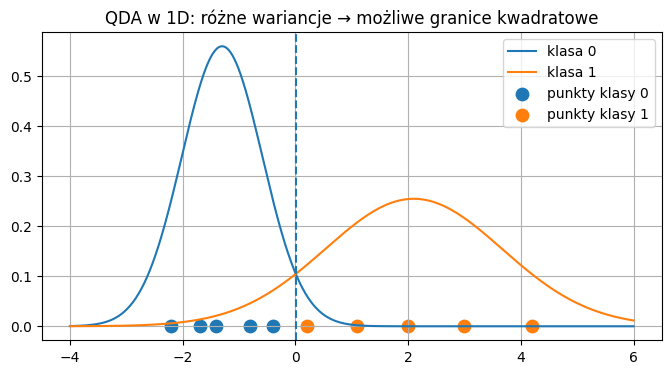

,przybliżona granica decyzyjna
0,0.015


In [3]:
xs = np.linspace(-4, 6, 600)
# gęstości bez scipy
def density(x, mu, var):
    return 1/np.sqrt(2*np.pi*var) * np.exp(-(x-mu)**2/(2*var))

p0 = density(xs, mu0, var0)
p1 = density(xs, mu1, var1)
# przybliżone przecięcia
sign = np.sign(p0-p1)
cross = []
for i in range(len(xs)-1):
    if sign[i] == 0 or sign[i] != sign[i+1]:
        cross.append((xs[i]+xs[i+1])/2)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(xs, p0, label='klasa 0')
ax.plot(xs, p1, label='klasa 1')
ax.scatter(x0, np.zeros_like(x0), s=80, label='punkty klasy 0')
ax.scatter(x1, np.zeros_like(x1), s=80, label='punkty klasy 1')
for c in cross:
    ax.axvline(c, linestyle='--')
ax.set_title('QDA w 1D: różne wariancje → możliwe granice kwadratowe')
ax.legend()
plt.show()

if cross:
    display(pd.DataFrame({'przybliżona granica decyzyjna': np.round(cross, 3)}))
else:
    print('Brak przecięcia w badanym zakresie xs.')

## 3. LDA vs QDA — co zmienia się matematycznie?

- **LDA**: zakłada wspólną kowariancję klas. W wyniku odejmowania log-gęstości składniki kwadratowe się skracają, więc granica jest liniowa.
- **QDA**: każda klasa ma własną kowariancję. Składniki kwadratowe zwykle się nie skracają, więc granica może być krzywa.

W 2D QDA porównuje funkcje postaci:

$$
g_k(x)=
-\frac{1}{2}\log |\Sigma_k|
-\frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
+\log p(y=k).
$$

To wyrażenie zawiera składniki kwadratowe względem cech $x_1,x_2$.

## 4. QDA w 2D: elipsy i krzywa granica decyzyjna

Przykład 1D dobrze pokazuje rachunek log-likelihood, ale dydaktycznie warto zobaczyć też przypadek 2D.

Tutaj klasy mają różne macierze kowariancji, więc QDA może dopasować inne elipsy gęstości do każdej klasy. LDA nadal musi użyć jednej wspólnej kowariancji, dlatego jego granica pozostaje liniowa.

Na rysunku elipsy pokazują przybliżony kształt rozkładu każdej klasy, a linia decyzyjna pokazuje, gdzie model zmienia predykcję.

,klasa,mu_x1,mu_x2,var_x1,var_x2,cov_x1_x2
0,0,-0.745,0.107,0.966,0.803,0.663
1,1,1.091,0.303,0.311,1.408,-0.006


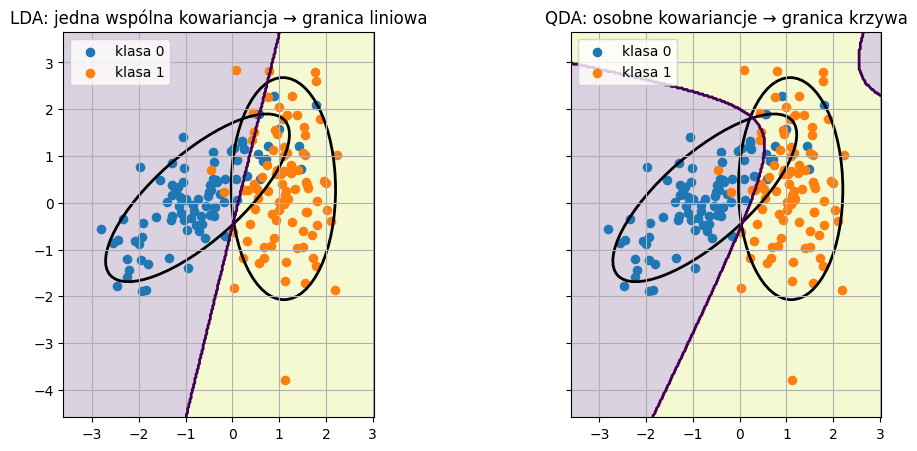

Trafność treningowa LDA: 0.9
Trafność treningowa QDA: 0.9


In [4]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from matplotlib.patches import Ellipse

rng = np.random.default_rng(7)
mu0_2d = np.array([-1.0, 0.0])
mu1_2d = np.array([1.1, 0.35])
cov0_2d = np.array([[1.20, 0.80], [0.80, 1.00]])
cov1_2d = np.array([[0.35, -0.10], [-0.10, 1.60]])

X0_2d = rng.multivariate_normal(mu0_2d, cov0_2d, size=90)
X1_2d = rng.multivariate_normal(mu1_2d, cov1_2d, size=90)
X_2d = np.vstack([X0_2d, X1_2d])
y_2d = np.r_[np.zeros(len(X0_2d), dtype=int), np.ones(len(X1_2d), dtype=int)]

summary = pd.DataFrame({
    'klasa': [0, 1],
    'mu_x1': [X0_2d[:, 0].mean(), X1_2d[:, 0].mean()],
    'mu_x2': [X0_2d[:, 1].mean(), X1_2d[:, 1].mean()],
    'var_x1': [np.cov(X0_2d.T)[0, 0], np.cov(X1_2d.T)[0, 0]],
    'var_x2': [np.cov(X0_2d.T)[1, 1], np.cov(X1_2d.T)[1, 1]],
    'cov_x1_x2': [np.cov(X0_2d.T)[0, 1], np.cov(X1_2d.T)[0, 1]],
})
display(summary.round(3))

lda_2d = LinearDiscriminantAnalysis().fit(X_2d, y_2d)
qda_2d = QuadraticDiscriminantAnalysis().fit(X_2d, y_2d)

x_min, x_max = X_2d[:, 0].min() - 0.8, X_2d[:, 0].max() + 0.8
y_min, y_max = X_2d[:, 1].min() - 0.8, X_2d[:, 1].max() + 0.8
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 260), np.linspace(y_min, y_max, 260))
grid = np.c_[xx.ravel(), yy.ravel()]

def add_cov_ellipse(ax, mean, cov, n_std=2.0):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mean, width=width, height=height, angle=angle, fill=False, linewidth=2)
    ax.add_patch(ell)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, model, title in [
    (axes[0], lda_2d, 'LDA: jedna wspólna kowariancja → granica liniowa'),
    (axes[1], qda_2d, 'QDA: osobne kowariancje → granica krzywa'),
]:
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.20)
    ax.contour(xx, yy, Z, levels=[0.5], linewidths=2)
    ax.scatter(X_2d[y_2d == 0, 0], X_2d[y_2d == 0, 1], s=35, label='klasa 0')
    ax.scatter(X_2d[y_2d == 1, 0], X_2d[y_2d == 1, 1], s=35, label='klasa 1')
    add_cov_ellipse(ax, X0_2d.mean(axis=0), np.cov(X0_2d.T))
    add_cov_ellipse(ax, X1_2d.mean(axis=0), np.cov(X1_2d.T))
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.legend(loc='best')
plt.show()

print('Trafność treningowa LDA:', round(lda_2d.score(X_2d, y_2d), 3))
print('Trafność treningowa QDA:', round(qda_2d.score(X_2d, y_2d), 3))

## 5. Confusion matrix: LDA i QDA jako klasyfikatory

Skoro LDA i QDA są metodami **nadzorowanymi**, możemy oceniać ich predykcje tak jak każdy klasyfikator.

Macierz pomyłek jest tu dobrym uzupełnieniem rysunku granicy:

```text
rysunek granicy        → gdzie model zmienia decyzję w przestrzeni cech,
macierz pomyłek        → które klasy model realnie myli na danych testowych.
```

Poniżej robimy mały podział train/test na danych 2D. To ważniejsze dydaktycznie niż sama trafność treningowa, bo test sprawdza punkty niewidziane przy uczeniu modelu.

,model,accuracy test,macro F1 test,liczba błędów
0,LDA,0.921,0.921,5
1,QDA,0.921,0.921,5


,pred 0,pred 1
true 0,30,2
true 1,3,28


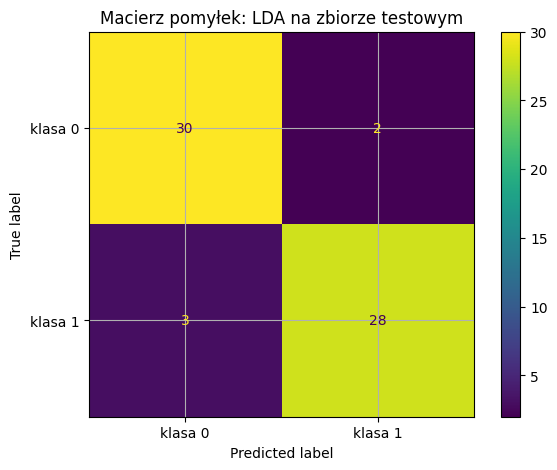

,pred 0,pred 1
true 0,30,2
true 1,3,28


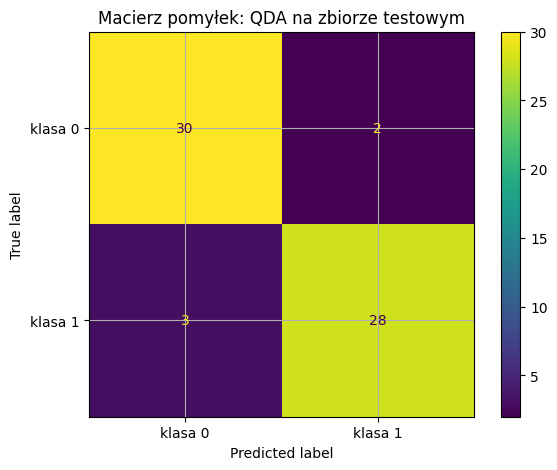

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d,
    test_size=0.35,
    random_state=13,
    stratify=y_2d,
)

models_eval = {
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(),
}

rows = []
preds = {}
for name, model in models_eval.items():
    model.fit(X2_train, y2_train)
    pred = model.predict(X2_test)
    preds[name] = pred
    rows.append({
        'model': name,
        'accuracy test': accuracy_score(y2_test, pred),
        'macro F1 test': f1_score(y2_test, pred, average='macro'),
        'liczba błędów': int(np.sum(pred != y2_test)),
    })

display(pd.DataFrame(rows).round(3))

for name, pred in preds.items():
    cm = confusion_matrix(y2_test, pred, labels=[0, 1])
    display(pd.DataFrame(cm, index=['true 0', 'true 1'], columns=['pred 0', 'pred 1']).style.set_caption(name))
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['klasa 0', 'klasa 1']).plot()
    plt.title(f'Macierz pomyłek: {name} na zbiorze testowym')
    plt.show()

## 6. Co tu jest ważne dydaktycznie?

- QDA nie jest „lepszą LDA” zawsze; jest bardziej elastyczna, więc przy małej próbie może łatwiej przeuczyć.
- Różne kowariancje klas oznaczają różne elipsy gęstości.
- Granica QDA wynika z porównania dwóch funkcji kwadratowych, dlatego w 2D może być krzywą.
- Macierz pomyłek nie mówi, jaki kształt ma granica; mówi tylko, jakie błędy robi klasyfikator. Dlatego najlepiej czytać ją razem z rysunkiem granicy.